# Activation Patching Experiment

This notebook performs **node-level interchange intervention** on `aya-expanse-8b`
to discover which attention heads and MLPs carry semantic role-identification information.

**Method:**
1. Build clean/corrupted sentence pairs that differ only in voice (active vs passive).
2. For each component, patch its output at position -1 from the corrupted run into the clean run.
3. Measure how much the model's prediction shifts toward the corrupted answer.

**Metric:** Normalized effect = (patched_logit_diff - clean_logit_diff) / (corrupted_logit_diff - clean_logit_diff)
- 0 = no effect, 1 = fully flipped to corrupted behavior

In [2]:
%pip install transformers torch accelerate bitsandbytes matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.0 MB/s eta 0:00:00:00:0100:01


In [3]:
from getpass import getpass
from huggingface_hub import login

token = getpass('Paste your Hugging Face read token: ').strip()
login(token=token, add_to_git_credential=False)
print('Authenticated.')

Authenticated.


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

## Loading Model and Tokenizer


In [5]:
MODEL_NAME = 'CohereForAI/aya-expanse-8b'

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print('Loading model in fp16...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto',
)
model.eval()
print('Model loaded.')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded.
Device: cuda


## Dataset Design

For each name pair (e.g. Alice/Bob) and verb, we create **4 patching pairs**:

| Type | Clean | Corrupted | Question | Correct (clean) |
|------|-------|-----------|----------|------------------|
| 1 | Alice stopped Bob. | Alice was stopped by Bob. | The one who stopped was | Alice |
| 2 | Alice was stopped by Bob. | Alice stopped Bob. | The one who stopped was | Bob |
| 3 | Alice stopped Bob. | Alice was stopped by Bob. | The one being stopped was | Bob |
| 4 | Alice was stopped by Bob. | Alice stopped Bob. | The one being stopped was | Alice |

- Types 1-2: agent question, both directions
- Types 3-4: patient question, both directions
- **3 name pairs x 1 verb x 4 types = 12 pairs total**

In [6]:
# Check which candidate names are single-token (with leading space, as they appear after "was")
candidate_names = [
    'Alice', 'Bob', 'John', 'Mary', 'Tom', 'Lisa',
    'James', 'Emma', 'David', 'Sarah', 'Paul', 'Anna',
    'Mark', 'Jane', 'Luke', 'Kate', 'Sam', 'Amy',
]

print('Checking which names are single-token (with leading space):')
print()
single_token_names = []
for name in candidate_names:
    tokens = tokenizer.encode(f' {name}', add_special_tokens=False)
    n_tok = len(tokens)
    status = 'SINGLE' if n_tok == 1 else f'MULTI ({n_tok})'
    print(f'  {name:10s} -> {status}  token_ids={tokens}')
    if n_tok == 1:
        single_token_names.append(name)

print()
print(f'Single-token names ({len(single_token_names)}): {single_token_names}')
print('Select 3 pairs from these for the experiment.')

Checking which names are single-token (with leading space):

  Alice      -> SINGLE  token_ids=[21287]
  Bob        -> SINGLE  token_ids=[9352]
  John       -> SINGLE  token_ids=[3439]
  Mary       -> SINGLE  token_ids=[7382]
  Tom        -> SINGLE  token_ids=[6253]
  Lisa       -> SINGLE  token_ids=[26509]
  James      -> SINGLE  token_ids=[6016]
  Emma       -> SINGLE  token_ids=[28940]
  David      -> SINGLE  token_ids=[5759]
  Sarah      -> SINGLE  token_ids=[19306]
  Paul       -> SINGLE  token_ids=[4822]
  Anna       -> SINGLE  token_ids=[14578]
  Mark       -> SINGLE  token_ids=[5715]
  Jane       -> SINGLE  token_ids=[10225]
  Luke       -> SINGLE  token_ids=[25568]
  Kate       -> SINGLE  token_ids=[25917]
  Sam        -> SINGLE  token_ids=[6009]
  Amy        -> SINGLE  token_ids=[29552]

Single-token names (18): ['Alice', 'Bob', 'John', 'Mary', 'Tom', 'Lisa', 'James', 'Emma', 'David', 'Sarah', 'Paul', 'Anna', 'Mark', 'Jane', 'Luke', 'Kate', 'Sam', 'Amy']
Select 3 pairs from t

In [ ]:
# Define 3 name pairs and verbs
name_verb_triplets = [
    ('Alice', 'Bob', 'warned'),
    ('John', 'Mary', 'helped'),
    ('Tom', 'Lisa', 'pushed'),
]

# Build 12 patching pairs (3 pairs x 4 types)
pairs = []
for name1, name2, verb in name_verb_triplets:
    # Type 1: active clean, agent question
    pairs.append({
        'clean': f'{name1} {verb} {name2}. The one who {verb} was',
        'corrupted': f'{name1} was {verb} by {name2}. The one who {verb} was',
        'correct_name': name1,
        'incorrect_name': name2,
        'question_type': 'agent',
        'clean_voice': 'active',
    })
    # Type 2: passive clean, agent question
    pairs.append({
        'clean': f'{name1} was {verb} by {name2}. The one who {verb} was',
        'corrupted': f'{name1} {verb} {name2}. The one who {verb} was',
        'correct_name': name2,
        'incorrect_name': name1,
        'question_type': 'agent',
        'clean_voice': 'passive',
    })
    # Type 3: active clean, patient question
    pairs.append({
        'clean': f'{name1} {verb} {name2}. The one being {verb} was',
        'corrupted': f'{name1} was {verb} by {name2}. The one being {verb} was',
        'correct_name': name2,
        'incorrect_name': name1,
        'question_type': 'patient',
        'clean_voice': 'active',
    })
    # Type 4: passive clean, patient question
    pairs.append({
        'clean': f'{name1} was {verb} by {name2}. The one being {verb} was',
        'corrupted': f'{name1} {verb} {name2}. The one being {verb} was',
        'correct_name': name1,
        'incorrect_name': name2,
        'question_type': 'patient',
        'clean_voice': 'passive',
    })

# Precompute token IDs for names
for p in pairs:
    cname = p['correct_name']
    iname = p['incorrect_name']
    p['correct_id'] = tokenizer.encode(f' {cname}', add_special_tokens=False)[0]
    p['incorrect_id'] = tokenizer.encode(f' {iname}', add_special_tokens=False)[0]

print(f'Built {len(pairs)} patching pairs.')
print()
for i, p in enumerate(pairs):
    voice = p['clean_voice']
    qtype = p['question_type']
    cname = p['correct_name']
    print(f'[{i:2d}] {voice:7s} {qtype:7s} correct={cname:5s} | {p["clean"]}')

Built 12 patching pairs.

[ 0] active  agent   correct=Alice | Alice warned Bob. The one who warned was
[ 1] passive agent   correct=Bob   | Alice was warned by Bob. The one who warned was
[ 2] active  patient correct=Bob   | Alice warned Bob. The one being warned was
[ 3] passive patient correct=Alice | Alice was warned by Bob. The one being warned was
[ 4] active  agent   correct=John  | John helped Mary. The one who helped was
[ 5] passive agent   correct=Mary  | John was helped by Mary. The one who helped was
[ 6] active  patient correct=Mary  | John helped Mary. The one being helped was
[ 7] passive patient correct=John  | John was helped by Mary. The one being helped was
[ 8] active  agent   correct=Tom   | Tom pushed Lisa. The one who pushed was
[ 9] passive agent   correct=Lisa  | Tom was pushed by Lisa. The one who pushed was
[10] active  patient correct=Lisa  | Tom pushed Lisa. The one being pushed was
[11] passive patient correct=Tom   | Tom was pushed by Lisa. The one being

## Patching Methodology

**Attention heads:** I hook the `o_proj` linear layer in each attention block with a `forward_pre_hook`.
The input to `o_proj` has shape `(batch, seq, n_heads * head_dim)`. I reshape to `(batch, seq, n_heads, head_dim)`,
replace one head's output at position -1 with the cached corrupted value, and reshape back.

**MLPs:** We hook each MLP module with a `forward_hook` and replace its output at position -1.

**Position -1** is the final token ("was"), which is naturally aligned between active and passive sentences
since both share the same prompt suffix. This avoids all alignment issues.

In [9]:
# Inspect model architecture to confirm hook points
layer0 = model.model.layers[0]
print('Layer 0 modules:')
for name, module in layer0.named_modules():
    if name:
        print(f'  {name}: {type(module).__name__}')

N_LAYERS = model.config.num_hidden_layers
N_HEADS = model.config.num_attention_heads
HIDDEN_SIZE = model.config.hidden_size
HEAD_DIM = HIDDEN_SIZE // N_HEADS

print()
print(f'N_LAYERS   = {N_LAYERS}')
print(f'N_HEADS    = {N_HEADS}')
print(f'HIDDEN_SIZE = {HIDDEN_SIZE}')
print(f'HEAD_DIM   = {HEAD_DIM}')
print()
print('Hook points:')
print('  Attention: model.model.layers[l].self_attn.o_proj (forward_pre_hook)')
print('  MLP:       model.model.layers[l].mlp (forward_hook)')

Layer 0 modules:
  self_attn: CohereAttention
  self_attn.q_proj: Linear
  self_attn.k_proj: Linear
  self_attn.v_proj: Linear
  self_attn.o_proj: Linear
  mlp: CohereMLP
  mlp.gate_proj: Linear
  mlp.up_proj: Linear
  mlp.down_proj: Linear
  mlp.act_fn: SiLUActivation
  input_layernorm: CohereLayerNorm

N_LAYERS   = 32
N_HEADS    = 32
HIDDEN_SIZE = 4096
HEAD_DIM   = 128

Hook points:
  Attention: model.model.layers[l].self_attn.o_proj (forward_pre_hook)
  MLP:       model.model.layers[l].mlp (forward_hook)


In [ ]:
# Baseline: verify model gets correct answer for clean and incorrect for corrupted
def compute_logit_diff(prompt, correct_id, incorrect_id):
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        logits = model(**inputs).logits[0, -1, :]
    return (logits[correct_id] - logits[incorrect_id]).item()

print('Baseline check (clean should be positive, corrupted should be negative):')
print()

clean_logit_diffs = []
corrupted_logit_diffs = []
valid_pairs = []

for i, p in enumerate(pairs):
    clean_ld = compute_logit_diff(p['clean'], p['correct_id'], p['incorrect_id'])
    corr_ld = compute_logit_diff(p['corrupted'], p['correct_id'], p['incorrect_id'])

    clean_logit_diffs.append(clean_ld)
    corrupted_logit_diffs.append(corr_ld)

    clean_ok = 'OK' if clean_ld > 0 else 'FAIL'
    corr_ok = 'OK' if corr_ld < 0 else 'FAIL'
    voice = p['clean_voice']
    qtype = p['question_type']
    cname = p['correct_name']
    print(f'[{i:2d}] clean={clean_ld:+8.2f} ({clean_ok})  corrupted={corr_ld:+8.2f} ({corr_ok})  '
          f'{voice:7s} {qtype:7s} {cname}')

    if clean_ld > 0 and corr_ld < 0:
        valid_pairs.append(i)

print()
print(f'Valid pairs: {len(valid_pairs)} / {len(pairs)}')
if len(valid_pairs) < len(pairs):
    print(f'WARNING: {len(pairs) - len(valid_pairs)} pairs failed baseline. Only valid pairs will be used.')

In [ ]:
# Cache corrupted activations at position -1 for all layers
# Attention: input to o_proj (concatenated head outputs)
# MLP: output of MLP module

n_valid = len(valid_pairs)
corrupted_attn_cache = {} 
corrupted_mlp_cache = {}

print(f'Caching corrupted activations for {n_valid} valid pairs...')
print()

for local_idx, pair_idx in enumerate(valid_pairs):
    p = pairs[pair_idx]
    attn_cache = {}
    mlp_cache = {}
    handles = []

    for l in range(N_LAYERS):
        # Attention: pre-hook on o_proj captures concatenated head outputs
        def make_attn_hook(layer_idx):
            def hook_fn(module, args):
                attn_cache[layer_idx] = args[0][0, -1, :].detach().clone()
            return hook_fn

        h = model.model.layers[l].self_attn.o_proj.register_forward_pre_hook(make_attn_hook(l))
        handles.append(h)

        # MLP: forward hook captures output
        def make_mlp_hook(layer_idx):
            def hook_fn(module, input, output):
                mlp_cache[layer_idx] = output[0, -1, :].detach().clone()
            return hook_fn

        h = model.model.layers[l].mlp.register_forward_hook(make_mlp_hook(l))
        handles.append(h)

    # Run corrupted forward pass
    inputs = tokenizer(p['corrupted'], return_tensors='pt').to(device)
    with torch.no_grad():
        model(**inputs)

    # Remove all hooks
    for h in handles:
        h.remove()

    corrupted_attn_cache[pair_idx] = attn_cache
    corrupted_mlp_cache[pair_idx] = mlp_cache

    prompt_preview = p['corrupted'][:50]
    print(f'  Cached pair {local_idx+1}/{n_valid}: {prompt_preview}...')

print('Done caching corrupted activations.')

Caching corrupted activations for 12 valid pairs...

  Cached pair 1/12: Alice was warned by Bob. The one who warned was...
  Cached pair 2/12: Alice warned Bob. The one who warned was...
  Cached pair 3/12: Alice was warned by Bob. The one being warned was...
  Cached pair 4/12: Alice warned Bob. The one being warned was...
  Cached pair 5/12: John was helped by Mary. The one who helped was...
  Cached pair 6/12: John helped Mary. The one who helped was...
  Cached pair 7/12: John was helped by Mary. The one being helped was...
  Cached pair 8/12: John helped Mary. The one being helped was...
  Cached pair 9/12: Tom was pushed by Lisa. The one who pushed was...
  Cached pair 10/12: Tom pushed Lisa. The one who pushed was...
  Cached pair 11/12: Tom was pushed by Lisa. The one being pushed was...
  Cached pair 12/12: Tom pushed Lisa. The one being pushed was...

Done caching corrupted activations.


In [ ]:
# Patch each attention head at position -1, one at a time
# For each (pair, layer, head): replace that head's o_proj input at pos -1
# with the cached corrupted value, measure logit_diff shift.

import sys

total_passes = N_HEADS * N_LAYERS * n_valid
print(f'Patching {N_HEADS * N_LAYERS} attention heads across {n_valid} valid pairs...')
print(f'Total forward passes: {total_passes}')
print()

head_effects = np.zeros((N_LAYERS, N_HEADS, n_valid))
pass_count = 0

def make_head_patch_hook(target_head, corrupted_head_val):
    def hook_fn(module, args):
        x = args[0].clone()  # (batch, seq, n_heads * head_dim)
        x_4d = x.view(x.shape[0], x.shape[1], N_HEADS, HEAD_DIM)
        x_4d[0, -1, target_head, :] = corrupted_head_val
        return (x_4d.reshape(x.shape),)
    return hook_fn

for p_local, pair_idx in enumerate(valid_pairs):
    p = pairs[pair_idx]
    clean_ld = clean_logit_diffs[pair_idx]
    corr_ld = corrupted_logit_diffs[pair_idx]
    denom = corr_ld - clean_ld  # typically negative

    inputs = tokenizer(p['clean'], return_tensors='pt').to(device)

    for layer in range(N_LAYERS):
        cached_attn = corrupted_attn_cache[pair_idx][layer]
        cached_heads = cached_attn.view(N_HEADS, HEAD_DIM)

        for head in range(N_HEADS):
            corrupted_head_val = cached_heads[head, :]

            handle = model.model.layers[layer].self_attn.o_proj.register_forward_pre_hook(
                make_head_patch_hook(head, corrupted_head_val)
            )

            with torch.no_grad():
                logits = model(**inputs).logits[0, -1, :]

            handle.remove()

            patched_ld = (logits[p['correct_id']] - logits[p['incorrect_id']]).item()
            head_effects[layer, head, p_local] = (patched_ld - clean_ld) / denom

            pass_count += 1
            pct = 100 * pass_count / total_passes
            print(f'\r  Forward pass {pass_count}/{total_passes} ({pct:.1f}%)  [pair {p_local+1}/{n_valid}, L{layer}H{head}]', end='')
            sys.stdout.flush()

print()

# Average over pairs
mean_head_effects = head_effects.mean(axis=2)

best = np.unravel_index(np.abs(mean_head_effects).argmax(), mean_head_effects.shape)


print(f'Largest absolute effect: {mean_head_effects[best]:.4f} at layer {best[0]}, head {best[1]}')
print(f'Head patching complete. Shape: {mean_head_effects.shape}')

Patching 1024 attention heads across 12 valid pairs...
Total forward passes: 12288

  Forward pass 12288/12288 (100.0%)  [pair 12/12, L31H31]
Largest absolute effect: 0.1693 at layer 20, head 13
Head patching complete. Shape: (32, 32)


In [ ]:
# Patch each MLP at position -1, one at a time
# For each (pair, layer): replace MLP output at pos -1 with cached corrupted value.

total_mlp_passes = N_LAYERS * n_valid
print(f'Patching {N_LAYERS} MLPs across {n_valid} valid pairs...')
print(f'Total forward passes: {total_mlp_passes}')
print()

mlp_effects = np.zeros((N_LAYERS, n_valid))
mlp_pass_count = 0

def make_mlp_patch_hook(corrupted_val):
    def hook_fn(module, input, output):
        if isinstance(output, tuple):
            out = output[0].clone()
            out[0, -1, :] = corrupted_val
            return (out,) + output[1:]
        else:
            out = output.clone()
            out[0, -1, :] = corrupted_val
            return out
    return hook_fn

for p_local, pair_idx in enumerate(valid_pairs):
    p = pairs[pair_idx]
    clean_ld = clean_logit_diffs[pair_idx]
    corr_ld = corrupted_logit_diffs[pair_idx]
    denom = corr_ld - clean_ld

    inputs = tokenizer(p['clean'], return_tensors='pt').to(device)

    for layer in range(N_LAYERS):
        corrupted_mlp_val = corrupted_mlp_cache[pair_idx][layer]

        handle = model.model.layers[layer].mlp.register_forward_hook(
            make_mlp_patch_hook(corrupted_mlp_val)
        )

        with torch.no_grad():
            logits = model(**inputs).logits[0, -1, :]

        handle.remove()

        patched_ld = (logits[p['correct_id']] - logits[p['incorrect_id']]).item()
        mlp_effects[layer, p_local] = (patched_ld - clean_ld) / denom

        mlp_pass_count += 1
        pct = 100 * mlp_pass_count / total_mlp_passes
        print(f'\r  Forward pass {mlp_pass_count}/{total_mlp_passes} ({pct:.1f}%)  [pair {p_local+1}/{n_valid}, L{layer}_MLP]', end='')
        sys.stdout.flush()

print()


mean_mlp_effects = mlp_effects.mean(axis=1)


print(f'Largest absolute MLP effect: {np.abs(mean_mlp_effects).max():.4f} at layer {np.abs(mean_mlp_effects).argmax()}')
print(f'MLP patching complete.')

Patching 32 MLPs across 12 valid pairs...
Total forward passes: 384

  Forward pass 384/384 (100.0%)  [pair 12/12, L31_MLP]
Largest absolute MLP effect: 0.1411 at layer 20
MLP patching complete.


## Plotting

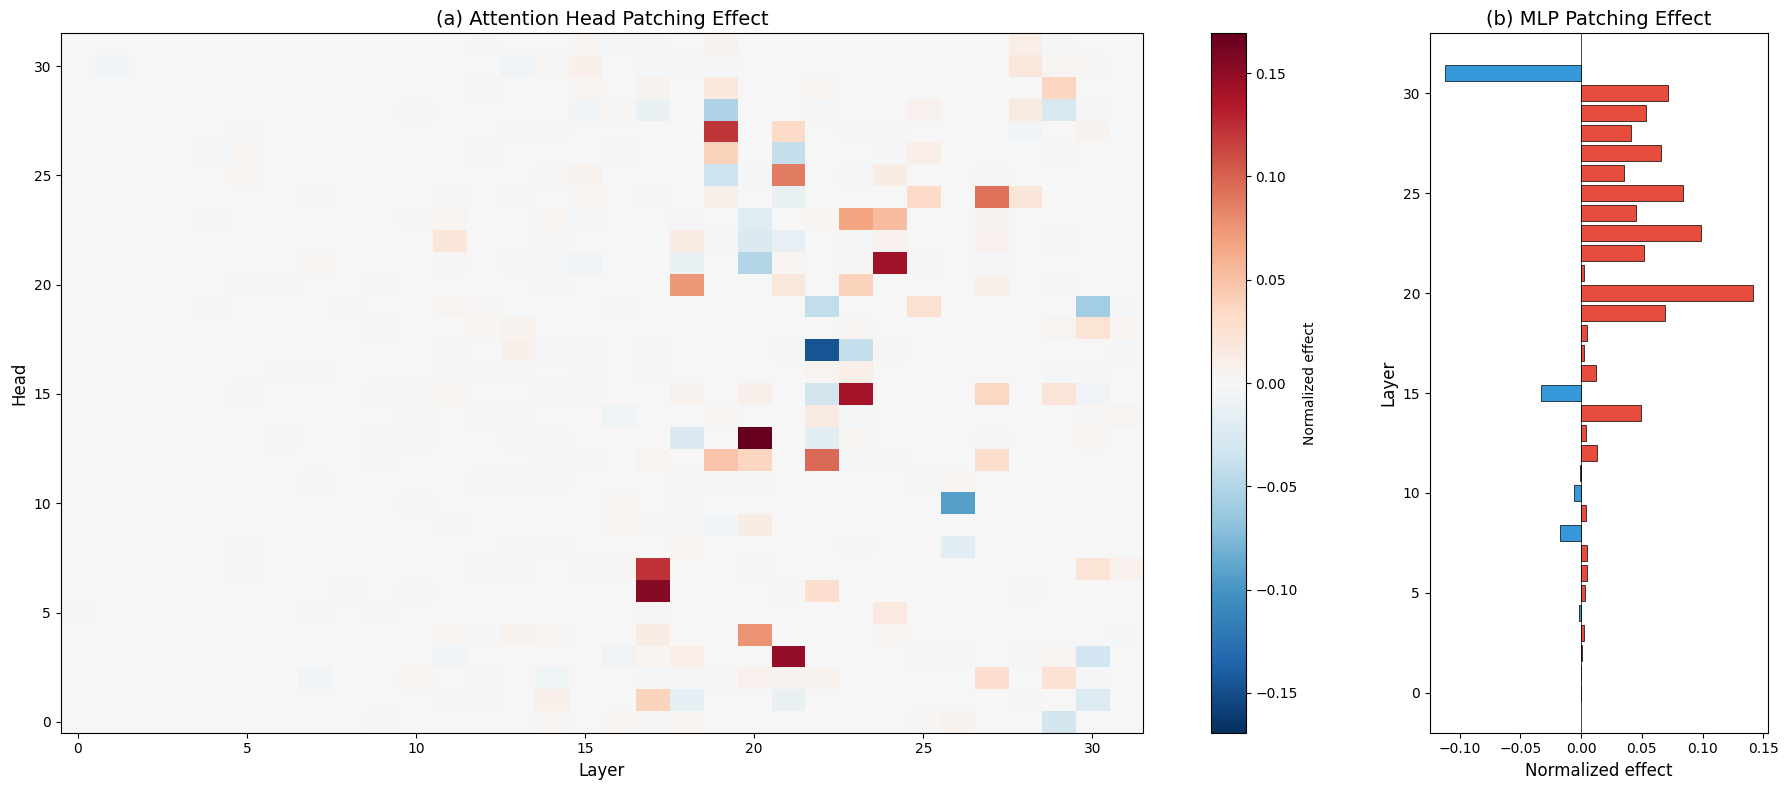

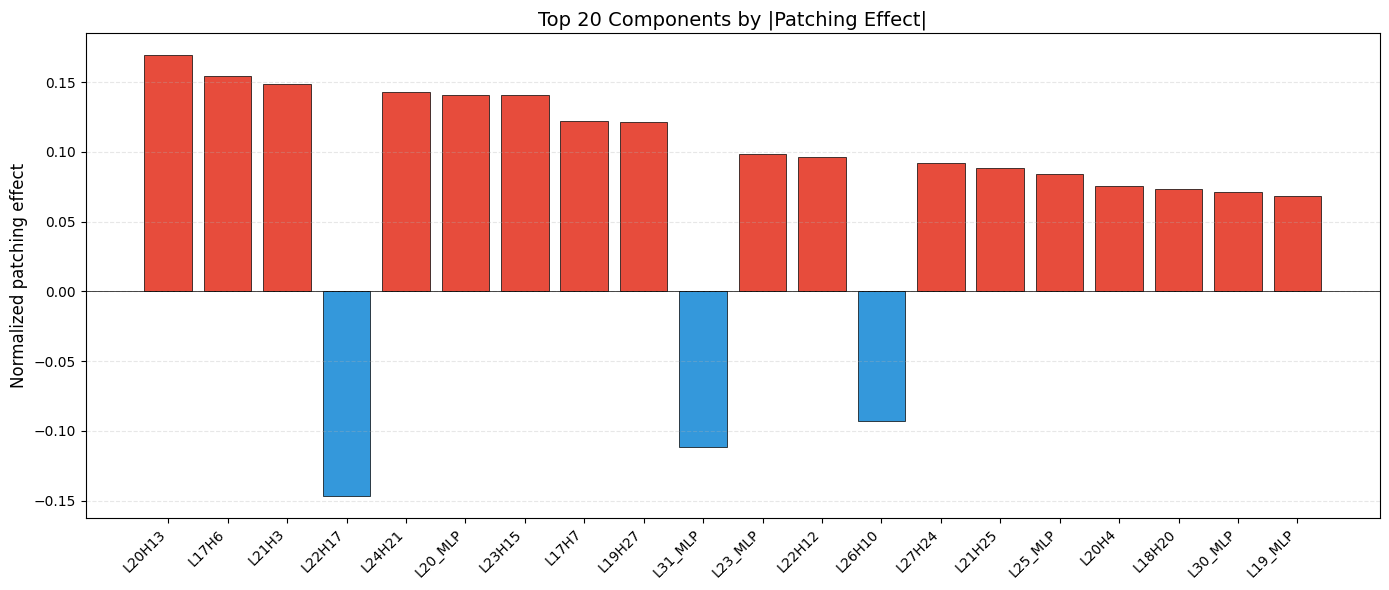

Top 20 components:
  L20H13        effect = +0.1693
  L17H6         effect = +0.1544
  L21H3         effect = +0.1486
  L22H17        effect = -0.1464
  L24H21        effect = +0.1433
  L20_MLP       effect = +0.1411
  L23H15        effect = +0.1405
  L17H7         effect = +0.1222
  L19H27        effect = +0.1211
  L31_MLP       effect = -0.1117
  L23_MLP       effect = +0.0982
  L22H12        effect = +0.0960
  L26H10        effect = -0.0926
  L27H24        effect = +0.0923
  L21H25        effect = +0.0883
  L25_MLP       effect = +0.0840
  L20H4         effect = +0.0758
  L18H20        effect = +0.0735
  L30_MLP       effect = +0.0711
  L19_MLP       effect = +0.0687


In [ ]:
# Attention head heatmap + MLP bar chart side by side 
# (a) Heatmap of mean_head_effects with layers on x-axis and heads on y-axis
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [4, 1]})

vmax_head = max(0.1, np.abs(mean_head_effects).max())
im = axes[0].imshow(
    mean_head_effects.T, aspect='auto', cmap='RdBu_r',
    vmin=-vmax_head, vmax=vmax_head, origin='lower'
)
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Head', fontsize=12)
axes[0].set_title('(a) Attention Head Patching Effect', fontsize=14)
plt.colorbar(im, ax=axes[0], label='Normalized effect')

# (b) MLP bar chart
colors_mlp = ['#e74c3c' if v > 0 else '#3498db' for v in mean_mlp_effects]
axes[1].barh(range(N_LAYERS), mean_mlp_effects, color=colors_mlp, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Normalized effect', fontsize=12)
axes[1].set_ylabel('Layer', fontsize=12)
axes[1].set_title('(b) MLP Patching Effect', fontsize=14)
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()